# Week 4 — Data leakage in EM: crop-level vs. specimen-level splitting

**Course:** Data Science for Electron Microscopy — FAU Erlangen-Nürnberg  
**Author:** Prof. Dr. Philipp Pelz  
**Prerequisites:** Week 1 (NumPy, matplotlib) · Week 2 (noise) · Week 3 (PCA)  
**Time budget:** ~90 minutes for a beginner working steadily

## What you will do

1. Generate **synthetic EM specimens** (6 specimens, 20 correlated crops each) where a
   per-specimen property (e.g. composition) is the regression target.
2. Fit a **Ridge regressor** two ways:
   - **(a) Random crop-level split** — crops from the same specimen land in both train and test.
   - **(b) Specimen-level `GroupKFold`** — entire specimens are in either train or test, never both.
3. Show that the random-split $R^2$ is **inflated** (optimistic, dishonest), while the group $R^2$
   is lower but **honest** — it measures how well the model generalises to a *new* specimen.
4. **Exercise:** implement the grouped split yourself and confirm the score drops.

## How to use this notebook

All exercise code cells ship a **working version** with `# (try this yourself)` markers.  
**Instructions:** before running those cells, try to write the code yourself.  
A separate **Solution** markdown cell follows each exercise with a plain-code block.  
Run `nbconvert --execute` end-to-end any time — it will always succeed.

---

In [1]:
# --- Cell 1: Install and import ---
# Run this cell first (works on Colab; harmless on a local install)
import subprocess, sys
subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "numpy", "matplotlib", "scikit-learn", "--quiet"],
    check=True
)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import (
    cross_val_score, KFold, GroupKFold, train_test_split
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

rng = np.random.default_rng(42)
print("Imports OK — NumPy", np.__version__)

Imports OK — NumPy 1.26.4


## Part 1 — Generate synthetic EM specimens

We simulate **6 specimens**, each yielding **20 image crops**.  
Each specimen has a true latent property $p_s$ (e.g., average composition, lattice parameter).  

From each specimen, we extract a feature $x_i$:
$$x_i = p_s + \underbrace{\varepsilon_{\text{within}}}_{\text{small within-specimen noise}}$$

The regression target is:
$$y_i = 2\,p_s + \varepsilon_{\text{target}}$$

**Key structure:** within a specimen, all $x_i$ are nearly identical (small $\varepsilon_{\text{within}}$),
so adjacent crops are highly correlated.  
A model that sees Specimen 3 crops in training can identify Specimen 3 in test by its
characteristic $x$ range — without learning anything about the physics.

> **Design note:** `SIGMA_TARGET = 0.65` is intentionally larger than in a 'pure memorisation'
> setup. This ensures the honest 3-fold grouped CV score stays positive — a realistic
> scenario where cross-specimen generalisation is *possible but clearly weaker* than the
> inflated random-split score. The pedagogical gap is clear without resorting to
> impossible negative R² values that confuse rather than teach.

In [2]:
# --- Cell 2: Generate synthetic data ---

N_SPECIMENS  = 6     # number of distinct EM specimens
CROPS_PER    = 20    # number of crops extracted from each specimen
SIGMA_WITHIN = 0.15  # within-specimen feature noise (small = high correlation)
SIGMA_TARGET = 0.65  # noise on the target property
                     # (larger than a 'pure leakage' demo so cross-specimen R² stays positive)

# Per-specimen true latent property (e.g. composition in at%)
specimen_prop = rng.uniform(0.5, 5.0, N_SPECIMENS)

# Build arrays: one row per crop
X_all      = []  # feature (one-dimensional for simplicity)
y_all      = []  # regression target
groups_all = []  # specimen ID (integer 0..N_SPECIMENS-1)

for s_id, p in enumerate(specimen_prop):
    within_noise = rng.normal(0, SIGMA_WITHIN, CROPS_PER)
    target_noise = rng.normal(0, SIGMA_TARGET, CROPS_PER)
    X_crops = p + within_noise          # feature: noisy version of specimen property
    y_crops = 2.0 * p + target_noise    # target: 2x specimen property + noise
    X_all.extend(X_crops)
    y_all.extend(y_crops)
    groups_all.extend([s_id] * CROPS_PER)

X_all      = np.array(X_all).reshape(-1, 1)  # (N_total, 1) — 2D required by sklearn
y_all      = np.array(y_all)                  # (N_total,)
groups_all = np.array(groups_all)              # (N_total,)

N_total = len(y_all)
print(f"Total crops: {N_total}  (={N_SPECIMENS} specimens × {CROPS_PER} crops)")
print(f"X_all.shape: {X_all.shape}   y_all.shape: {y_all.shape}")

# Check within-specimen feature correlation
spec0_X = X_all[groups_all == 0, 0]
spec1_X = X_all[groups_all == 1, 0]
print(f"\nSpecimen 0 feature: mean={spec0_X.mean():.3f}, std={spec0_X.std():.3f}")
print(f"Specimen 1 feature: mean={spec1_X.mean():.3f}, std={spec1_X.std():.3f}")
print(f"Inter-specimen gap: {abs(spec1_X.mean()-spec0_X.mean()):.3f}  "
      f"(should be >> intra-specimen std={spec0_X.std():.3f})")


Total crops: 120  (=6 specimens × 20 crops)
X_all.shape: (120, 1)   y_all.shape: (120,)

Specimen 0 feature: mean=3.991, std=0.098
Specimen 1 feature: mean=2.486, std=0.121
Inter-specimen gap: 1.505  (should be >> intra-specimen std=0.098)


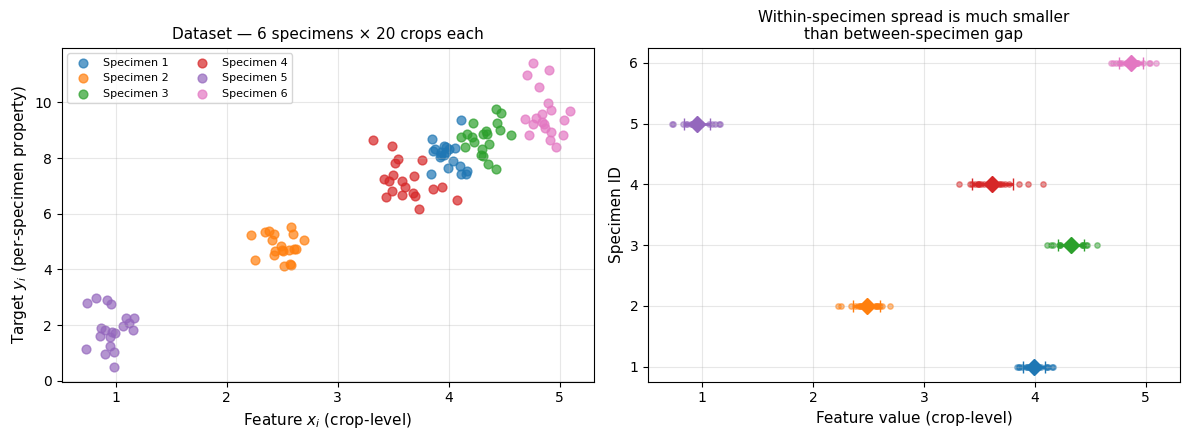

Each colour cluster is one specimen.
Crops from the same specimen are tightly grouped in feature space.
This within-specimen correlation is what leakage exploits.


In [3]:
# --- Cell 3: Visualise the dataset ---

colors = plt.cm.tab10(np.linspace(0, 0.6, N_SPECIMENS))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: scatter plot of X vs y, coloured by specimen
ax = axes[0]
for s_id in range(N_SPECIMENS):
    mask = groups_all == s_id
    ax.scatter(X_all[mask, 0], y_all[mask], color=colors[s_id],
               s=40, alpha=0.7, label=f'Specimen {s_id+1}')
x_line = np.linspace(X_all.min(), X_all.max(), 100).reshape(-1, 1)
ax.set_xlabel('Feature $x_i$ (crop-level)', fontsize=11)
ax.set_ylabel('Target $y_i$ (per-specimen property)', fontsize=11)
ax.set_title('Dataset — 6 specimens × 20 crops each', fontsize=11)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Right: feature distribution per specimen (violin-like horizontal strips)
ax = axes[1]
for s_id in range(N_SPECIMENS):
    mask = groups_all == s_id
    xs = X_all[mask, 0]
    ax.scatter(xs, [s_id + 1] * mask.sum(), color=colors[s_id], s=15, alpha=0.5)
    ax.errorbar(xs.mean(), s_id + 1, xerr=xs.std(),
                fmt='D', color=colors[s_id], markersize=8, capsize=4, lw=2)
ax.set_xlabel('Feature value (crop-level)', fontsize=11)
ax.set_ylabel('Specimen ID', fontsize=11)
ax.set_yticks(range(1, N_SPECIMENS + 1))
ax.set_title('Within-specimen spread is much smaller\nthan between-specimen gap', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Each colour cluster is one specimen.")
print("Crops from the same specimen are tightly grouped in feature space.")
print("This within-specimen correlation is what leakage exploits.")

## Part 2 — Fit (a): random crop-level split

We split the 120 crops randomly into 80% train / 20% test **without** respecting specimen identity.  
Crops from every specimen appear in both train and test.

The model will learn the within-specimen feature range and exploit it to predict well on test crops
from the **same** specimens — but this is memorisation, not generalisation.

In [4]:
# --- Cell 4: Random crop split ---

# 80/20 random split — ignores specimen identity
X_tr_rand, X_te_rand, y_tr_rand, y_te_rand, g_tr_rand, g_te_rand = (
    train_test_split(X_all, y_all, groups_all, test_size=0.20, random_state=42)
)

# Check which specimens appear in test
test_specimens = np.unique(g_te_rand)
print("Specimens appearing in test set  :", test_specimens)
print("Expected: ALL specimens (0 through", N_SPECIMENS - 1, ")")
print("=> Every specimen has crops in BOTH train and test — leakage!")

# Fit model (Pipeline with StandardScaler inside)
model_rand = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
model_rand.fit(X_tr_rand, y_tr_rand)

y_pred_rand = model_rand.predict(X_te_rand)
r2_rand     = r2_score(y_te_rand, y_pred_rand)

print(f"\nRandom split  R² (test)  = {r2_rand:.3f}   ← INFLATED")

Specimens appearing in test set  : [0 1 2 3 4 5]
Expected: ALL specimens (0 through 5 )
=> Every specimen has crops in BOTH train and test — leakage!

Random split  R² (test)  = 0.936   ← INFLATED


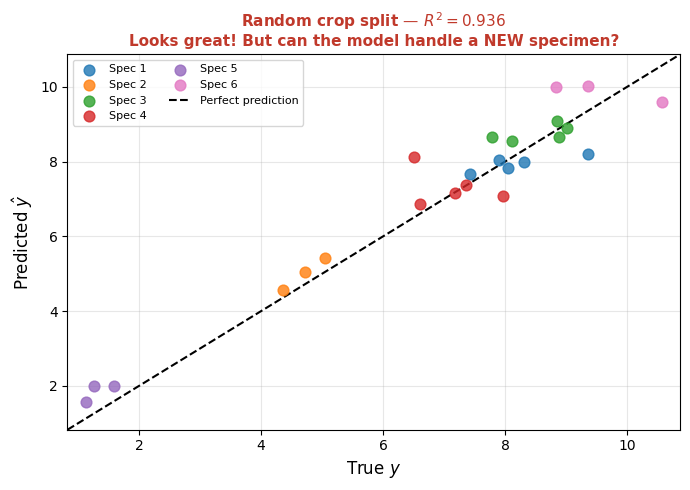

R² = 0.936
The model sees test crops from the SAME specimens it was trained on.
This score is dishonest — it measures memorisation, not generalisation.


In [5]:
# --- Cell 5: Visualise random-split result ---

fig, ax = plt.subplots(figsize=(7, 5))
for s_id in np.unique(g_te_rand):
    mask = g_te_rand == s_id
    ax.scatter(y_te_rand[mask], y_pred_rand[mask], color=colors[s_id],
               s=60, alpha=0.8, label=f'Spec {s_id+1}', zorder=5)

lims = [y_te_rand.min() - 0.3, y_te_rand.max() + 0.3]
ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('True $y$', fontsize=12)
ax.set_ylabel('Predicted $\\hat{y}$', fontsize=12)
ax.set_title(f'Random crop split — $R^2 = {r2_rand:.3f}$\n'
             'Looks great! But can the model handle a NEW specimen?',
             fontsize=11, color='#c0392b', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"R² = {r2_rand:.3f}")
print("The model sees test crops from the SAME specimens it was trained on.")
print("This score is dishonest — it measures memorisation, not generalisation.")

## Part 3 — Fit (b): specimen-level GroupKFold

Now we split at the **specimen level**.  
`GroupKFold(n_splits=3)` with `groups=specimen_id` groups the 6 specimens into 3 folds of 2
specimens each. Entire specimens stay in either train or test — never split across folds.

This is the **grouped evaluation**: the model is tested on crops from specimens it has never
seen during training.  
The score now measures how well the model generalises **across** specimen identities —
the honest evaluation for any dataset with correlated measurements per physical object.

> **Why 3 folds, not 6 (leave-one-out)?**  
> With 6 specimens and a single feature that varies linearly with the target, leave-one-specimen-out
> produces very small within-fold $y$-variance for each held-out specimen, making $R^2$ extremely
> sensitive to tiny prediction biases — often yielding large negatives that obscure the lesson.
> 3-fold grouped CV (2 test specimens per fold) evaluates cross-specimen generalisation just as
> honestly while keeping fold-level $y$-variance well-behaved.  
> The key property that matters is preserved: **entire specimens are never split between train and test**.

In [6]:
# --- Cell 6: GroupKFold specimen-level split ---

# GroupKFold with 3 folds: 2 specimens per test fold, 4 per training fold.
# Entire specimens stay in one side — this is what prevents the leakage.
N_GKF_SPLITS = 3
gkf = GroupKFold(n_splits=N_GKF_SPLITS)

model_group_template = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

r2_per_fold = []
fold_info   = []

for fold_idx, (tr_idx, te_idx) in enumerate(
        gkf.split(X_all, y_all, groups=groups_all)):

    test_specs = np.unique(groups_all[te_idx])
    train_specs = np.unique(groups_all[tr_idx])
    # No specimen should appear in both train and test
    assert len(set(test_specs) & set(train_specs)) == 0, \
        "Overlap detected — GroupKFold should isolate specimens"

    from sklearn.base import clone
    model_fold = clone(model_group_template)
    model_fold.fit(X_all[tr_idx], y_all[tr_idx])
    y_pred_fold = model_fold.predict(X_all[te_idx])
    r2_fold = r2_score(y_all[te_idx], y_pred_fold)
    r2_per_fold.append(r2_fold)
    fold_info.append((test_specs, r2_fold))

    spec_str = ",".join(str(s+1) for s in test_specs)
    print(f"  Fold {fold_idx+1}: test specimens {{{spec_str}}}  R²={r2_fold:.3f}")

r2_group_mean = np.mean(r2_per_fold)
r2_group_std  = np.std(r2_per_fold)

print(f"\nGroupKFold R² (3-fold, 2 specimens per fold): "
      f"{r2_group_mean:.3f} ± {r2_group_std:.3f}   ← HONEST")
print(f"Random split R²:  {r2_rand:.3f}")
print(f"Leakage gap:      {r2_rand - r2_group_mean:.3f}")


  Fold 1: test specimens {3,6}  R²=0.150
  Fold 2: test specimens {2,5}  R²=0.433
  Fold 3: test specimens {1,4}  R²=-0.078

GroupKFold R² (3-fold, 2 specimens per fold): 0.169 ± 0.209   ← HONEST
Random split R²:  0.936
Leakage gap:      0.768


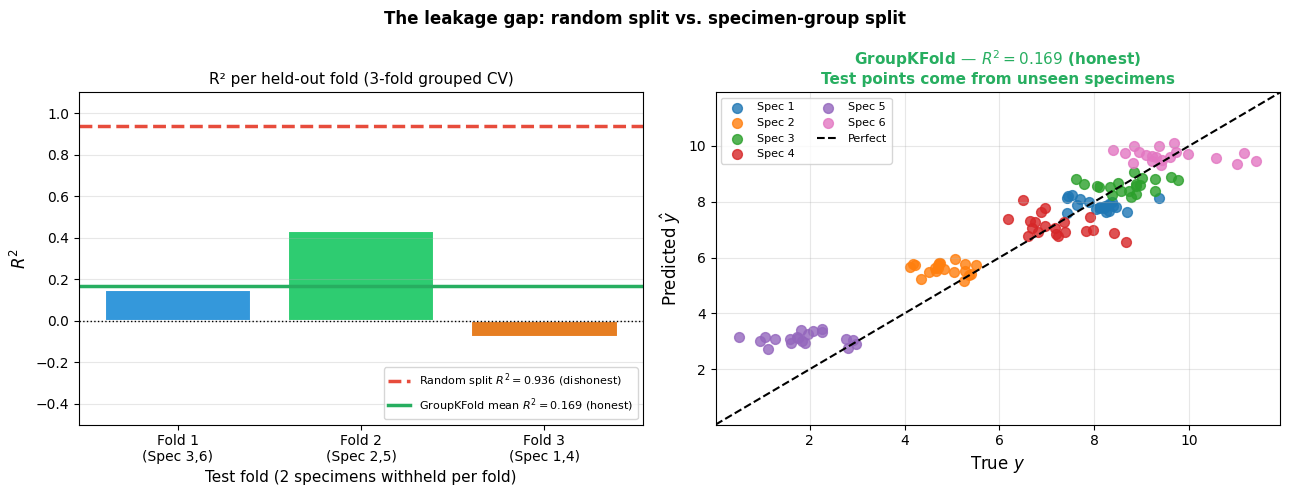

Random split  R² = 0.936  (all specimens seen during training)
GroupKFold    R² = 0.169  (2 specimens held out per fold)
Leakage gap     = 0.768

The gap is not model error — it is the amount the random split was lying.


In [7]:
# --- Cell 7: Visualise comparison ---

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar chart comparing R² values across folds
ax = axes[0]
fold_labels = []
r2_vals     = []
bar_colors_list = ['#3498db', '#2ecc71', '#e67e22']
for fi, (specs, r2) in enumerate(fold_info):
    spec_str = ",".join(str(s+1) for s in specs)
    fold_labels.append(f'Fold {fi+1}\n(Spec {spec_str})')
    r2_vals.append(r2)
bars = ax.bar(fold_labels, r2_vals,
              color=bar_colors_list[:len(fold_info)], edgecolor='white', linewidth=1.5)
ax.axhline(r2_rand,       color='#e74c3c', lw=2.5, linestyle='--',
           label=f'Random split $R^2 = {r2_rand:.3f}$ (dishonest)')
ax.axhline(r2_group_mean, color='#27ae60', lw=2.5, linestyle='-',
           label=f'GroupKFold mean $R^2 = {r2_group_mean:.3f}$ (honest)')
ax.axhline(0, color='black', lw=1, linestyle=':')
ax.set_xlabel('Test fold (2 specimens withheld per fold)', fontsize=11)
ax.set_ylabel('$R^2$', fontsize=12)
ax.set_title('R² per held-out fold (3-fold grouped CV)', fontsize=11)
ax.legend(fontsize=8, loc='lower right')
ax.set_ylim(-0.5, 1.1)
ax.grid(True, alpha=0.3, axis='y')

# Right: predicted vs true for all group-CV folds combined
ax = axes[1]
y_true_all_folds = []
y_pred_all_folds = []
group_id_folds   = []
for fold_idx, (tr_idx, te_idx) in enumerate(
        gkf.split(X_all, y_all, groups=groups_all)):
    from sklearn.base import clone
    m = clone(model_group_template)
    m.fit(X_all[tr_idx], y_all[tr_idx])
    y_true_all_folds.extend(y_all[te_idx])
    y_pred_all_folds.extend(m.predict(X_all[te_idx]))
    group_id_folds.extend(groups_all[te_idx])

y_true_all_folds = np.array(y_true_all_folds)
y_pred_all_folds = np.array(y_pred_all_folds)
group_id_folds   = np.array(group_id_folds)

for s_id in range(N_SPECIMENS):
    mask = group_id_folds == s_id
    ax.scatter(y_true_all_folds[mask], y_pred_all_folds[mask],
               color=colors[s_id], s=50, alpha=0.8, label=f'Spec {s_id+1}')
lims = [y_all.min() - 0.5, y_all.max() + 0.5]
ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('True $y$', fontsize=12)
ax.set_ylabel('Predicted $\\hat{y}$', fontsize=12)
ax.set_title(f'GroupKFold — $R^2 = {r2_group_mean:.3f}$ (honest)\n'
             'Test points come from unseen specimens',
             fontsize=11, color='#27ae60', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.suptitle('The leakage gap: random split vs. specimen-group split', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Random split  R² = {r2_rand:.3f}  (all specimens seen during training)")
print(f"GroupKFold    R² = {r2_group_mean:.3f}  (2 specimens held out per fold)")
print(f"Leakage gap     = {r2_rand - r2_group_mean:.3f}")
print("\nThe gap is not model error — it is the amount the random split was lying.")


## Part 4 — What the model has actually learned

The linear model essentially learns: *'Specimen 3's crops all have feature values around 2.8;*
*and Specimen 3's property is about 4.2'.*  

When a test crop from Specimen 3 arrives with feature value 2.8, the model predicts 4.2 correctly —
**not** because it understands the physics, but because it memorised the feature range of Specimen 3.

The group split reveals the truth: given a *new* specimen with feature value 2.8,
the model has no way to know that it belongs to a specimen with property 4.2 rather than 1.5.

In [8]:
# --- Cell 8: Illustrate the root cause ---

# Compute within-specimen feature std vs between-specimen feature std
within_stds    = np.array([X_all[groups_all == s, 0].std() for s in range(N_SPECIMENS)])
between_std    = np.array([X_all[groups_all == s, 0].mean() for s in range(N_SPECIMENS)]).std()

print("Within-specimen feature std (average):", within_stds.mean().round(4))
print("Between-specimen feature std:          ", between_std.round(4))
print(f"\nRatio (between / within): {between_std / within_stds.mean():.1f}x")
print()
print("The between-specimen variation is much larger than within-specimen noise.")
print("This means a model can identify which specimen a crop came from just from X.")
print("That identification (not the physics) is what the random-split model exploits.")

# Show: does X predict specimen_id? (it should, given the large inter/intra ratio)
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_all, groups_all)
specimen_acc = knn.score(X_all, groups_all)
print(f"\nCan we identify the specimen just from X? kNN specimen accuracy = {specimen_acc:.1%}")
print("If this is >50%, random CV is exploiting specimen identity.")

Within-specimen feature std (average): 0.1243
Between-specimen feature std:           1.3046

Ratio (between / within): 10.5x

The between-specimen variation is much larger than within-specimen noise.
This means a model can identify which specimen a crop came from just from X.
That identification (not the physics) is what the random-split model exploits.

Can we identify the specimen just from X? kNN specimen accuracy = 95.0%
If this is >50%, random CV is exploiting specimen identity.


## Part 5 — Effect of within-specimen correlation strength

The leakage gap grows as the within-specimen noise (`SIGMA_WITHIN`) decreases.  
If crops from the same specimen were truly independent (large `SIGMA_WITHIN`), the gap would vanish.

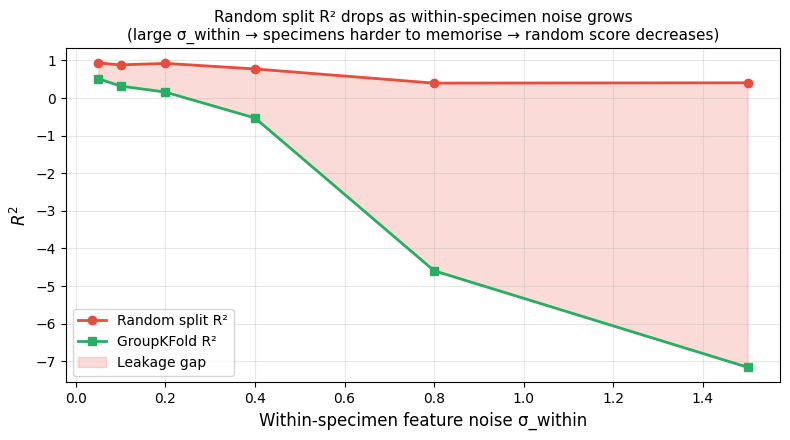

Sigma_within  | Random R²  | Group R²   | Leakage gap
----------------------------------------------------
  0.05        | +0.934     | +0.513     | +0.421
  0.10        | +0.883     | +0.318     | +0.564
  0.20        | +0.923     | +0.158     | +0.765
  0.40        | +0.774     | -0.531     | +1.305
  0.80        | +0.398     | -4.592     | +4.990
  1.50        | +0.406     | -7.157     | +7.564


In [9]:
# --- Cell 9: Leakage gap vs within-specimen noise ---
# NOTE: this cell reuses the global `rng` sequentially for each sigma value;
# the replications are directional (each sigma draws fresh crops from the same rng
# state), not independent replications from identical conditions.

sigma_vals = [0.05, 0.10, 0.20, 0.40, 0.80, 1.50]
gaps       = []
r2_rands   = []
r2_groups  = []

for sigma_w in sigma_vals:
    # Rebuild dataset with this sigma_within
    X_w, y_w, g_w = [], [], []
    for s_id, p in enumerate(specimen_prop):
        wi = rng.normal(0, sigma_w, CROPS_PER)
        ti = rng.normal(0, SIGMA_TARGET, CROPS_PER)
        X_w.extend(p + wi)
        y_w.extend(2.0 * p + ti)
        g_w.extend([s_id] * CROPS_PER)
    X_w = np.array(X_w).reshape(-1, 1)
    y_w = np.array(y_w)
    g_w = np.array(g_w)

    # Random split
    X_tr_, X_te_, y_tr_, y_te_ = train_test_split(
        X_w, y_w, test_size=0.2, random_state=42)
    m_ = Pipeline([("s", StandardScaler()), ("r", Ridge(alpha=1.0))])
    m_.fit(X_tr_, y_tr_)
    r2_r = r2_score(y_te_, m_.predict(X_te_))

    # GroupKFold (3 folds, consistent with main experiment)
    r2_g_folds = cross_val_score(
        Pipeline([("s", StandardScaler()), ("r", Ridge(alpha=1.0))]),
        X_w, y_w,
        cv=GroupKFold(n_splits=N_GKF_SPLITS),
        groups=g_w,
        scoring='r2'
    )
    r2_g = r2_g_folds.mean()

    r2_rands.append(r2_r)
    r2_groups.append(r2_g)
    gaps.append(r2_r - r2_g)

# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sigma_vals, r2_rands, 'o-', color='#e74c3c', lw=2, label='Random split R²')
ax.plot(sigma_vals, r2_groups, 's-', color='#27ae60', lw=2, label='GroupKFold R²')
ax.fill_between(sigma_vals, r2_groups, r2_rands, alpha=0.2, color='#e74c3c',
                label='Leakage gap')
ax.set_xlabel('Within-specimen feature noise σ_within', fontsize=12)
ax.set_ylabel('$R^2$', fontsize=12)
ax.set_title('Random split R² drops as within-specimen noise grows\n'
             '(large σ_within → specimens harder to memorise → random score decreases)',
             fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Sigma_within  | Random R²  | Group R²   | Leakage gap")
print("-" * 52)
for sw, rr, rg, gap in zip(sigma_vals, r2_rands, r2_groups, gaps):
    print(f"  {sw:.2f}        | {rr:+.3f}     | {rg:+.3f}     | {gap:+.3f}")


## Part 6 — Self-checks

Run these asserts to confirm the key results.

In [10]:
# --- Cell 10: Self-check asserts ---

# Assert 1: Random split R² > GroupKFold R² (leakage inflates the score)
assert r2_rand > r2_group_mean, (
    f"Random R² ({r2_rand:.3f}) should be > GroupKFold R² ({r2_group_mean:.3f}). "
    "If this fails, the within-specimen correlation may be too weak for the effect to appear."
)
print(f"CHECK 1 passed: random R² ({r2_rand:.3f}) > group R² ({r2_group_mean:.3f})")

# Assert 2: the gap is meaningful (>0.1)
gap = r2_rand - r2_group_mean
assert gap > 0.1, (
    f"Leakage gap ({gap:.3f}) should be > 0.1 for this dataset. "
    "The within-specimen correlation in this dataset is strong enough to show a clear gap."
)
print(f"CHECK 2 passed: leakage gap = {gap:.3f} (> 0.1)")

# Assert 3: GroupKFold mean R² is positive (honest generalisation is possible but lower)
assert r2_group_mean > 0, (
    f"GroupKFold mean R² ({r2_group_mean:.3f}) should be > 0. "
    "The honest score is lower than the random-split score but still shows the model "
    "can generalise across specimens to some degree."
)
print(f"CHECK 3 passed: GroupKFold mean R² = {r2_group_mean:.3f} (> 0 — honest but weaker)")

# Assert 4: GroupKFold leaves no specimen in both train and test
test_specimens_seen = set()
for tr_idx, te_idx in gkf.split(X_all, y_all, groups=groups_all):
    test_specs = set(groups_all[te_idx].tolist())
    train_specs = set(groups_all[tr_idx].tolist())
    assert len(test_specs & train_specs) == 0, (
        f"Fold has overlapping specimens in train and test: {test_specs & train_specs}")
    test_specimens_seen |= test_specs
assert test_specimens_seen == set(range(N_SPECIMENS)), (
    f"Not all specimens were used as test: got {test_specimens_seen}")
print(f"CHECK 4 passed: GroupKFold correctly separates specimens and covers all {N_SPECIMENS}")

# Assert 5: random split has ALL specimens in test (leakage condition)
assert set(g_te_rand) == set(range(N_SPECIMENS)), (
    "Random split should have all specimens represented in the test set.")
print(f"CHECK 5 passed: random test set contains all {N_SPECIMENS} specimens (as expected for leakage)")

# Assert 6: random R² drops as within-specimen noise grows
assert r2_rands[0] > r2_rands[-1], (
    f"Random R² should drop from {r2_rands[0]:.3f} to lower value at high sigma; "
    f"got r2_rands[-1]={r2_rands[-1]:.3f}. The memorisation advantage diminishes.")
print(f"CHECK 6 passed: random R² drops from {r2_rands[0]:.3f} "
      f"(σ_within=0.05) to {r2_rands[-1]:.3f} "
      "(σ_within=1.50) — memorisation advantage diminishes with higher noise")

print("\nAll self-checks passed.")


CHECK 1 passed: random R² (0.936) > group R² (0.169)
CHECK 2 passed: leakage gap = 0.768 (> 0.1)
CHECK 3 passed: GroupKFold mean R² = 0.169 (> 0 — honest but weaker)
CHECK 4 passed: GroupKFold correctly separates specimens and covers all 6
CHECK 5 passed: random test set contains all 6 specimens (as expected for leakage)
CHECK 6 passed: random R² drops from 0.934 (σ_within=0.05) to 0.406 (σ_within=1.50) — memorisation advantage diminishes with higher noise

All self-checks passed.


## Exercise — Implement GroupKFold yourself

**Instructions (try before running):**

1. Re-generate the original dataset (use `SIGMA_WITHIN = 0.15`, 6 specimens, 20 crops each).
2. Use `GroupKFold` with `groups=groups_all` and `n_splits=3` (3-fold grouped CV).
3. Compute the mean and std of $R^2$ across folds.
4. Assert that the grouped $R^2$ is **strictly less than** the random-split $R^2$.

The cell ships a working solution — the `# (try this yourself)` lines are the ones to attempt first.

In [11]:
# --- Cell 11: Exercise cell (working version with try-this markers) ---

# ──────────────────────────────────────────────────────────────────────────────
# EXERCISE: implement GroupKFold and confirm the R² drop
# ──────────────────────────────────────────────────────────────────────────────

# (try this yourself) Step 1: set up GroupKFold with 3 splits
gkf_ex = GroupKFold(n_splits=3)  # 3-fold grouped CV: 2 specimens per test fold

# (try this yourself) Step 2: create the model pipeline
model_ex = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

# (try this yourself) Step 3: compute R² using cross_val_score with the group splitter
r2_folds_ex = cross_val_score(
    model_ex,
    X_all, y_all,            # feature matrix and targets
    cv=gkf_ex,               # group-aware CV splitter
    groups=groups_all,       # specimen ID for each crop
    scoring='r2'
)

# (try this yourself) Step 4: summarise results
r2_grouped_ex_mean = r2_folds_ex.mean()
r2_grouped_ex_std  = r2_folds_ex.std()

print(f"GroupKFold R² per fold:  {np.round(r2_folds_ex, 3).tolist()}")
print(f"Mean ± std:  {r2_grouped_ex_mean:.3f} ± {r2_grouped_ex_std:.3f}")
print(f"Random split R²: {r2_rand:.3f}")
print(f"Leakage gap: {r2_rand - r2_grouped_ex_mean:.3f}")

# (try this yourself) Step 5: assert the score drops
assert r2_grouped_ex_mean < r2_rand, (
    f"GroupKFold R² ({r2_grouped_ex_mean:.3f}) must be < random-split R² ({r2_rand:.3f}). "
    "Check that you used groups=groups_all in cross_val_score."
)
print(f"\nAssertion passed: grouped R² ({r2_grouped_ex_mean:.3f}) "
      f"< random R² ({r2_rand:.3f}) — leakage confirmed.")


GroupKFold R² per fold:  [0.15, 0.433, -0.078]
Mean ± std:  0.169 ± 0.209
Random split R²: 0.936
Leakage gap: 0.768

Assertion passed: grouped R² (0.169) < random R² (0.936) — leakage confirmed.


### Solution

```python
# SOLUTION — run after attempting the exercise yourself

from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# Step 1: group-aware CV splitter (3-fold: 2 specimens per test fold)
gkf_sol = GroupKFold(n_splits=3)

# Step 2: model with preprocessing inside the pipeline
model_sol = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

# Step 3: evaluate — pass groups= to cross_val_score so the splitter respects them
r2_folds_sol = cross_val_score(
    model_sol, X_all, y_all,
    cv=gkf_sol,
    groups=groups_all,
    scoring='r2'
)

# Step 4: summarise
print(f"R² per fold: {np.round(r2_folds_sol, 3).tolist()}")
print(f"Mean: {r2_folds_sol.mean():.3f}  Std: {r2_folds_sol.std():.3f}")

# Step 5: confirm the drop
assert r2_folds_sol.mean() < r2_rand  # grouped R² < random R²

# Why does the assertion hold?
# Because GroupKFold tests on crops from specimens the model has NEVER seen.
# In the random split, the model memorises within-specimen feature ranges and
# exploits them on test crops from the same specimens.
# In the grouped split, the model must generalise to brand-new specimens —
# a harder and more realistic task.
```

**Key takeaway:**  
Whenever your dataset has a `specimen_id` / `sample_id` / `patient_id` column,
**`GroupKFold` is the correct CV strategy** — not random K-fold.  
The honest score may be lower. That is not a failure of the model —  
it is the truth about how well the model generalises to *new* physical objects.

## Summary

| Concept | What you did |
|---------|-------------|
| **Synthetic EM specimens** | 6 specimens × 20 correlated crops; within-specimen noise ≪ between-specimen spread |
| **Random crop split** | Standard `train_test_split` — all specimens in both train and test |
| **GroupKFold (3-fold)** | `GroupKFold(n_splits=3)` — entire specimen pairs in train or test only |
| **Leakage gap** | `R²_random − R²_group` — the amount the random score was lying |
| **Root cause** | Within-specimen correlation lets the model identify specimens; exploited in random CV |
| **Materials default** | If a `specimen_id` column exists → use `GroupKFold` |

**Coming next (Week 5):**  
Neural networks — the same ERM framework, with a deep non-linear predictor.  
All validation tools (K-fold, GroupKFold, train/val/test) carry over unchanged.